In [1]:
import pandas as pd
import numpy as np
import nltk
from nltk.corpus import stopwords
from nltk.stem import SnowballStemmer
import re

In [3]:
import pandas as pd
df = pd.read_csv('/content/Dataset.5000.Registros.Marz.ID.Sintomas.Enfermedad.Especialidad.csv', encoding='latin1', engine='python', on_bad_lines='skip', sep=';')
display(df.head())
#df = pd.read_csv('../Datos/Dataset.5000.Registros.Marz.ID.Sintomas.Enfermedad.Especialidad.csv', encoding='latin1', engine='python', on_bad_lines='skip', sep=';')

,record_id,symptoms_text,disease,specialty
0,1,Desde hace 2 días me pasa esto: dolor de garga...,Resfriado común,MEDICINA GENERAL
1,2,Llevo 2 días con estornudos y dolor de gargant...,Resfriado común,MEDICINA GENERAL
2,3,"Tengo estornudos y tos leve desde hace 1 día, ...",Resfriado común,MEDICINA GENERAL
3,4,Llevo 1 día con congestión nasal y dolor de ga...,Resfriado común,MEDICINA GENERAL
4,5,"Me empezó hace 5 días: ojos llorosos intenso, ...",Resfriado común,MEDICINA GENERAL


Una vez que hayas revisado los datos, dime cuál columna contiene el texto que quieres usar para el clasificador TF-IDF y cuál columna es la etiqueta (clase) que quieres predecir.

### 1. Preprocesamiento de Texto

El primer paso es limpiar la columna `symptoms_text` para prepararla para el análisis. Esto incluye:

*   Convertir todo el texto a minúsculas.
*   Eliminar signos de puntuación y números.
*   Eliminar las palabras vacías (stopwords), que son palabras comunes que no añaden mucho significado (e.g., 'el', 'la', 'un').
*   (Opcional) Realizar lematización o *stemming* para reducir las palabras a su raíz.

Para esto, necesitaremos las librerías `nltk`.

In [4]:

# Descargar recursos necesarios de NLTK (solo la primera vez)
try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    nltk.download('stopwords')

# Inicializar stemmer y stopwords en español
stemmer = SnowballStemmer('spanish')
stopwords_spanish = stopwords.words('spanish')

def preprocess_text(text):
    # Convertir a minúsculas
    text = text.lower()
    # Eliminar puntuación y números
    text = re.sub(r'[^a-záéíóúüñ\s]', '', text) # Mantener letras, tildes y ñ
    # Tokenizar (dividir en palabras) y eliminar stopwords y aplicar stemming
    words = text.split()
    words = [stemmer.stem(word) for word in words if word not in stopwords_spanish]
    return ' '.join(words)

# Aplicar el preprocesamiento a la columna 'symptoms_text'
df['symptoms_processed'] = df['symptoms_text'].apply(preprocess_text)

# Mostrar las primeras filas con la nueva columna procesada
display(df[['symptoms_text', 'symptoms_processed', 'specialty']].head())

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


,symptoms_text,symptoms_processed,specialty
0,Desde hace 2 días me pasa esto: dolor de garga...,hac dias pas dolor gargant fuert ojos lloros i...,MEDICINA GENERAL
1,Llevo 2 días con estornudos y dolor de gargant...,llev dias estornud dolor gargant intens ademas...,MEDICINA GENERAL
2,"Tengo estornudos y tos leve desde hace 1 día, ...",estornud tos lev hac dia ultim malest general,MEDICINA GENERAL
3,Llevo 1 día con congestión nasal y dolor de ga...,llev dia congestion nasal dolor gargant ademas...,MEDICINA GENERAL
4,"Me empezó hace 5 días: ojos llorosos intenso, ...",empez hac dias ojos lloros intens estornud fue...,MEDICINA GENERAL


In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Inicializar el TfidfVectorizer
tfidf_vectorizer = TfidfVectorizer(max_features=5000) # Puedes ajustar max_features según necesidad

# Ajustar y transformar los datos preprocesados
X_tfidf = tfidf_vectorizer.fit_transform(df['symptoms_processed'])

# Mostrar la forma de la matriz TF-IDF (número de documentos, número de características/palabras)
print(f"Forma de la matriz TF-IDF: {X_tfidf.shape}")

# Opcional: mostrar algunas de las palabras (características) que aprendió el vectorizador
print("Primeras 10 características (palabras):", tfidf_vectorizer.get_feature_names_out()[:10])

Forma de la matriz TF-IDF: (5252, 344)
Primeras 10 características (palabras): ['abdom' 'abdominal' 'acidez' 'acompañ' 'acut' 'ademas' 'agach' 'agrand'
 'ahog' 'air']


In [6]:
# Definir la variable objetivo (y)
y = df['specialty']

print(f"Forma de la variable objetivo (y): {y.shape}")
print("Primeras 5 etiquetas:")
print(y.head())

Forma de la variable objetivo (y): (5252,)
Primeras 5 etiquetas:
0    MEDICINA GENERAL
1    MEDICINA GENERAL
2    MEDICINA GENERAL
3    MEDICINA GENERAL
4    MEDICINA GENERAL
Name: specialty, dtype: object


In [11]:
from sklearn.decomposition import TruncatedSVD

In [12]:
# Inicializar TruncatedSVD
# Se elige un número de componentes (por ejemplo, 100), pero se puede ajustar
svd_model = TruncatedSVD(n_components=100, random_state=42)

# Aplicar SVD a la matriz TF-IDF
X_svd = svd_model.fit_transform(X_tfidf)

print(f"Forma de la matriz TF-IDF después de SVD: {X_svd.shape}")

Forma de la matriz TF-IDF después de SVD: (5252, 100)


In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split # Se añade el import de train_test_split

# Inicializar el modelo de Regresión Logística
# Se añade max_iter para asegurar la convergencia en algunos casos
classifier_model = LogisticRegression(max_iter=1000, random_state=42)

# Dividir los datos en conjuntos de entrenamiento y prueba usando X_svd
X_train_svd, X_test_svd, y_train, y_test = train_test_split(X_svd, y, test_size=0.2, random_state=42)

# Entrenar el modelo con los datos de entrenamiento transformados por SVD
classifier_model.fit(X_train_svd, y_train)

print("Modelo de Regresión Logística entrenado exitosamente con SVD.")

Modelo de Regresión Logística entrenado exitosamente con SVD.


In [14]:
from sklearn.model_selection import train_test_split

# Dividir los datos en conjuntos de entrenamiento y prueba usando X_svd
X_train_svd, X_test_svd, y_train, y_test = train_test_split(X_svd, y, test_size=0.2, random_state=42)

# Mostrar las formas de los conjuntos resultantes
print(f"Forma de X_train_svd: {X_train_svd.shape}")
print(f"Forma de X_test_svd: {X_test_svd.shape}")
print(f"Forma de y_train: {y_train.shape}")
print(f"Forma de y_test: {y_test.shape}")

Forma de X_train_svd: (4201, 100)
Forma de X_test_svd: (1051, 100)
Forma de y_train: (4201,)
Forma de y_test: (1051,)


Precisión del modelo: 0.98

Informe de Clasificación:
                                          precision    recall  f1-score   support

                             ALERGOLOGÍA       1.00      0.98      0.99        44
           ANGIOLOGÍA Y CIRUGÍA VASCULAR       1.00      1.00      1.00        29
                       APARATO DIGESTIVO       0.99      1.00      0.99       236
                             CARDIOLOGÍA       0.75      0.60      0.67         5
 CIRUGÍA GENERAL Y DEL APARATO DIGESTIVO       1.00      1.00      1.00        24
DERMATOLOGÍA MÉDICO-QUIRÚRGICA Y VENEREO       0.93      1.00      0.96       107
              ENDOCRINOLOGÍA Y NUTRICIÓN       0.98      0.98      0.98        98
               GINECOLOGÍA Y OBSTETRICIA       0.00      0.00      0.00         0
                        MEDICINA GENERAL       0.88      1.00      0.94        52
                        MEDICINA INTERNA       1.00      1.00      1.00        96
                              NEFROLOGÍA   

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

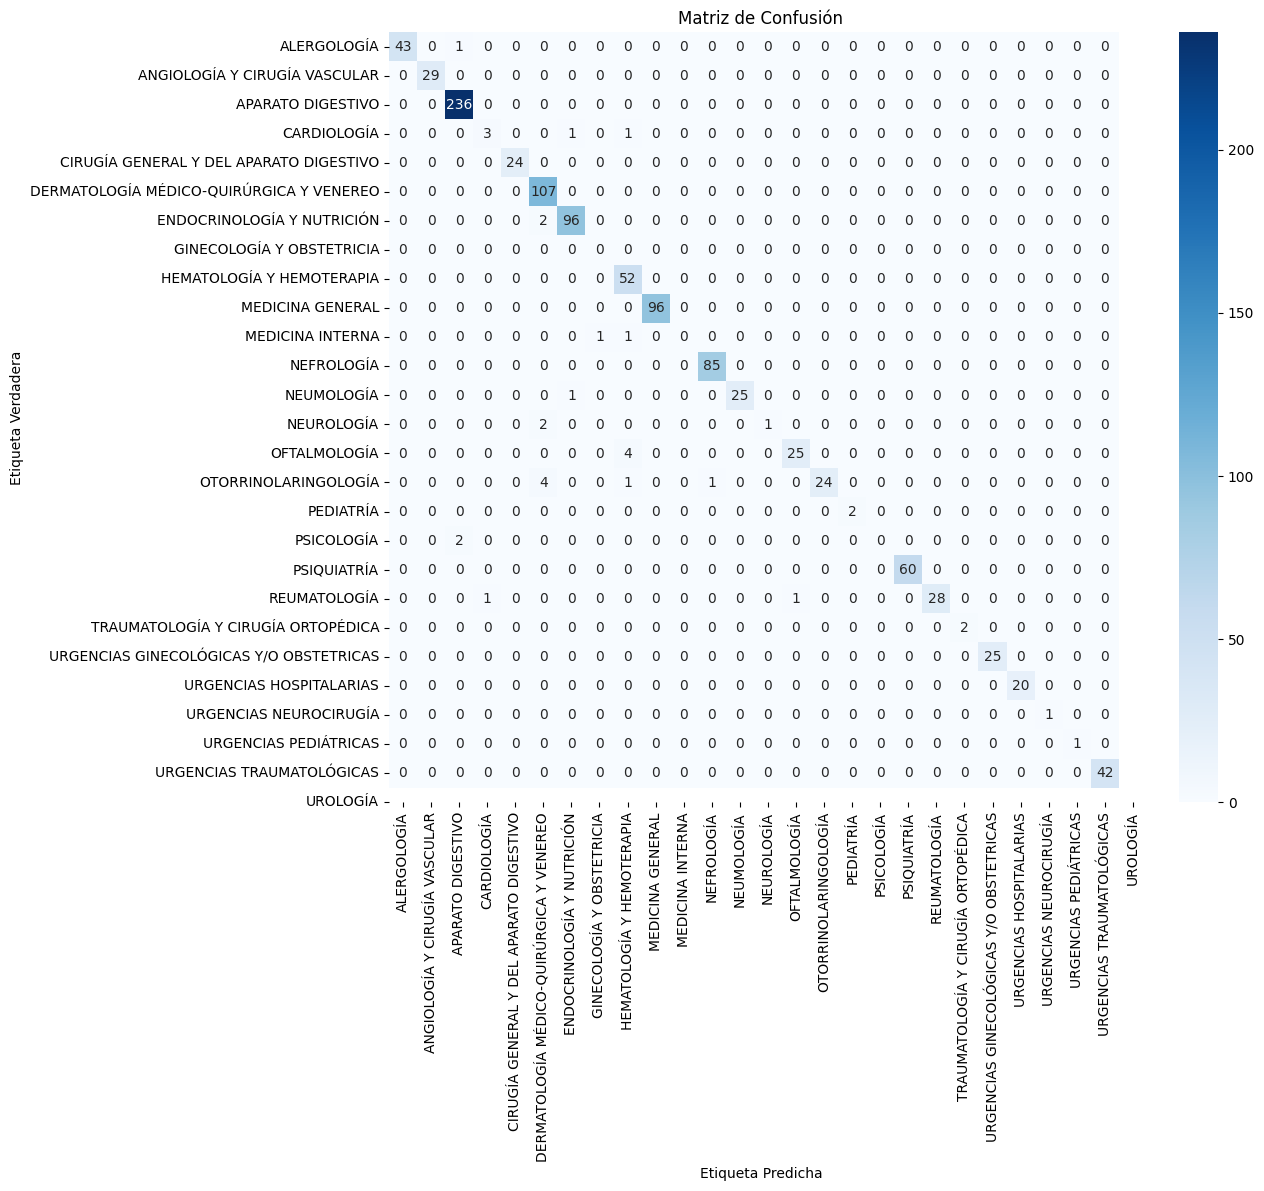

In [15]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Realizar predicciones sobre el conjunto de prueba transformado por SVD
y_pred = classifier_model.predict(X_test_svd)

# Calcular la precisión del modelo
accuracy = accuracy_score(y_test, y_pred)
print(f"Precisión del modelo: {accuracy:.2f}")

# Mostrar un informe de clasificación detallado
print("\nInforme de Clasificación:")
print(classification_report(y_test, y_pred))

# Calcular la matriz de confusión
conf_matrix = confusion_matrix(y_test, y_pred)

# Visualizar la matriz de confusión
plt.figure(figsize=(12, 10))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=classifier_model.classes_, yticklabels=classifier_model.classes_)
plt.xlabel('Etiqueta Predicha')
plt.ylabel('Etiqueta Verdadera')
plt.title('Matriz de Confusión')
plt.show()

### Identificación de Clases Difíciles de Predecir

Vamos a analizar el informe de clasificación programáticamente para identificar las clases con bajo rendimiento (precisión, recall o F1-score de 0.0) y aquellas con un `support` muy bajo en el conjunto de prueba, lo que las hace inherentemente difíciles de predecir o evaluar.

In [16]:
from sklearn.metrics import classification_report

# Obtener el informe de clasificación como un diccionario
report = classification_report(y_test, y_pred, output_dict=True)

difficult_classes = {
    'zero_performance': [],
    'low_support_and_performance': []
}

print("\n--- Clases con rendimiento cero o indefinido (Precision, Recall, F1-Score = 0.0) ---")
for class_name, metrics in report.items():
    # Ignorar las métricas generales como 'accuracy', 'macro avg', 'weighted avg'
    if class_name in ['accuracy', 'macro avg', 'weighted avg']:
        continue

    # Convertir métricas a float para comparación
    precision = float(metrics['precision'])
    recall = float(metrics['recall'])
    f1_score = float(metrics['f1-score'])
    support = int(metrics['support'])

    if precision == 0.0 or recall == 0.0 or f1_score == 0.0:
        difficult_classes['zero_performance'].append({
            'class': class_name,
            'precision': precision,
            'recall': recall,
            'f1-score': f1_score,
            'support': support
        })
        print(f"- Clase: {class_name}, Precision: {precision:.2f}, Recall: {recall:.2f}, F1-Score: {f1_score:.2f}, Support: {support}")

print("\n--- Clases con bajo soporte (menos de 5 muestras) y posible bajo rendimiento ---")
# Reiniciar para identificar de nuevo, evitando duplicar si ya están en 'zero_performance'
low_support_classes = []
for class_name, metrics in report.items():
    if class_name in ['accuracy', 'macro avg', 'weighted avg']:
        continue

    support = int(metrics['support'])
    if support > 0 and support < 5: # Consideramos 'bajo soporte' si hay menos de 5 muestras reales
        precision = float(metrics['precision'])
        recall = float(metrics['recall'])
        f1_score = float(metrics['f1-score'])
        low_support_classes.append({
            'class': class_name,
            'precision': precision,
            'recall': recall,
            'f1-score': f1_score,
            'support': support
        })
        print(f"- Clase: {class_name}, Precision: {precision:.2f}, Recall: {recall:.2f}, F1-Score: {f1_score:.2f}, Support: {support}")

if not difficult_classes['zero_performance'] and not low_support_classes:
    print("No se identificaron clases con rendimiento cero o soporte extremadamente bajo.")
else:
    print("\nAnálisis completo de clases difíciles de predecir.")


--- Clases con rendimiento cero o indefinido (Precision, Recall, F1-Score = 0.0) ---
- Clase: GINECOLOGÍA Y OBSTETRICIA, Precision: 0.00, Recall: 0.00, F1-Score: 0.00, Support: 0
- Clase: NEFROLOGÍA, Precision: 0.00, Recall: 0.00, F1-Score: 0.00, Support: 2
- Clase: PSIQUIATRÍA, Precision: 0.00, Recall: 0.00, F1-Score: 0.00, Support: 2

--- Clases con bajo soporte (menos de 5 muestras) y posible bajo rendimiento ---
- Clase: NEFROLOGÍA, Precision: 0.00, Recall: 0.00, F1-Score: 0.00, Support: 2
- Clase: OFTALMOLOGÍA, Precision: 1.00, Recall: 0.33, F1-Score: 0.50, Support: 3
- Clase: PSICOLOGÍA, Precision: 1.00, Recall: 1.00, F1-Score: 1.00, Support: 2
- Clase: PSIQUIATRÍA, Precision: 0.00, Recall: 0.00, F1-Score: 0.00, Support: 2
- Clase: URGENCIAS GINECOLÓGICAS Y/O OBSTETRICAS, Precision: 1.00, Recall: 1.00, F1-Score: 1.00, Support: 2
- Clase: URGENCIAS PEDIÁTRICAS, Precision: 1.00, Recall: 1.00, F1-Score: 1.00, Support: 1
- Clase: URGENCIAS TRAUMATOLÓGICAS, Precision: 1.00, Recall: 1

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_